# Contradicting Claims in the Knowledge Graph

**Question.** Can we use the extracted knowledge graph to surface *contradicting
claims*? Concretely:

1. Find **nodes (entities) that have multiple claims** attached. How many such
   nodes are there, out of how many candidates?
2. Take a **random sample** of those multi-claim nodes and inspect whether any of
   them carry contradicting claims.

## Data-model reality (read this first)

The relational store (`work/knowledge_extraction.db`) does **not** store an
explicit entity to claim foreign key:

- `claims` rows persist only `id, text, chunk_id, confidence,
  supporting_figure_id, supporting_table_id`. The domain `Claim` model has
  `subject / predicate / object`, but those are dropped on persistence.
- The `relationships` table (incl. `SUPPORTS_CLAIM` edges) is **orphaned**: its
  endpoint ids are bare 16-hex hashes that do not reconcile with `entities.id`,
  `claims.id`, or `chunks.id` (likely a different/older id-hashing scheme).

So the only reliable entity to claim link available is **textual**: an entity is
treated as "having" a claim when the entity's `name` or one of its aliases
(length >= 4) appears in the claim text. This is a lexical proxy, not ground
truth, and it is what this experiment uses.

In [1]:
import re
import sqlite3
from collections import defaultdict
from pathlib import Path

import pandas as pd


def find_db() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        cand = base / "work" / "knowledge_extraction.db"
        if cand.exists():
            return cand
    raise FileNotFoundError("work/knowledge_extraction.db not found from " + str(here))


DB = find_db()
con = sqlite3.connect(DB)
cur = con.cursor()

counts = {
    t: cur.execute(f"select count(*) from {t}").fetchone()[0]
    for t in ("documents", "chunks", "claims", "entities", "relationships", "entity_aliases")
}
print("db:", DB)
pd.Series(counts, name="rows").to_frame()

db: C:\_CODE\AdvancedRAG\knowledge_extraction\work\knowledge_extraction.db


,rows
documents,4
chunks,1678
claims,1723
entities,3638
relationships,1787
entity_aliases,4042


## 1. Link claims to nodes by name / alias, then count multi-claim nodes

We exclude structural entity types (`Section`, `Claim`, `Figure`, `Table`) — they
are not real-world "things" we'd reason about contradictions over. A node counts
a claim when any of its names/aliases (>= 4 chars) appears in the claim text
(case-insensitive, whitespace-normalised).

In [2]:
SKIP_TYPES = {"Section", "Claim", "Figure", "Table"}


def norm(s: str) -> str:
    return re.sub(r"\s+", " ", (s or "").lower()).strip()


claims = [(cid, norm(t)) for cid, t in cur.execute("select id, text from claims")]
entities = cur.execute("select id, name, type from entities").fetchall()

alias_map: dict[str, set[str]] = defaultdict(set)
for cid, al in cur.execute("select canonical_id, alias from entity_aliases"):
    al = norm(al)
    if len(al) >= 4:
        alias_map[cid].add(al)

ent_type = {eid: etype for eid, _, etype in entities}
ent_name = {eid: name for eid, name, _ in entities}

ent_claims: dict[str, set[str]] = defaultdict(set)
considered = 0
for eid, name, etype in entities:
    if etype in SKIP_TYPES:
        continue
    names = {n for n in ({norm(name)} | alias_map.get(eid, set())) if len(n) >= 4}
    if not names:
        continue
    considered += 1
    for cid, text in claims:
        if any(n in text for n in names):
            ent_claims[eid].add(cid)

multi = {e: cs for e, cs in ent_claims.items() if len(cs) >= 2}
print(f"candidate nodes (typed, name >= 4 chars): {considered}")
print(f"nodes with >= 1 claim:  {len(ent_claims)}")
print(f"nodes with >= 2 claims: {len(multi)}  ({100 * len(multi) / considered:.1f}% of candidates)")

candidate nodes (typed, name >= 4 chars): 2228
nodes with >= 1 claim:  1324
nodes with >= 2 claims: 606  (27.2% of candidates)


### Claim-count distribution and breakdown by entity type

,num_nodes
claims_per_node (10 = 10+),
1,718
2,237
3,98
4,53
5,42
6,26
7,31
8,12
9,10


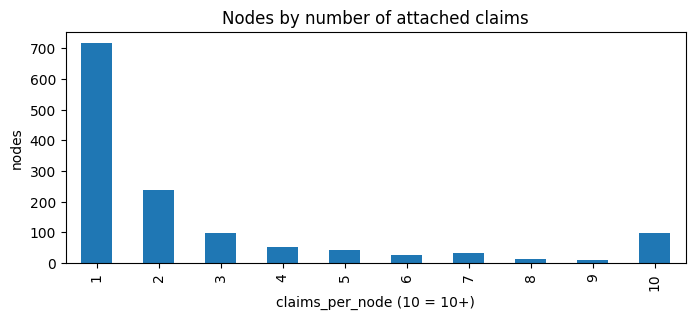

In [3]:
dist: dict[int, int] = defaultdict(int)
for cs in ent_claims.values():
    dist[min(len(cs), 10)] += 1
dist_s = pd.Series(dict(sorted(dist.items())), name="num_nodes")
dist_s.index.name = "claims_per_node (10 = 10+)"

ax = dist_s.plot(kind="bar", figsize=(8, 3), title="Nodes by number of attached claims")
ax.set_ylabel("nodes")
dist_s.to_frame()

In [4]:
by_type: dict[str, list[int]] = defaultdict(lambda: [0, 0])
for e, cs in ent_claims.items():
    by_type[ent_type[e]][0] += 1
    if len(cs) >= 2:
        by_type[ent_type[e]][1] += 1

by_type_df = (
    pd.DataFrame(
        [(t, a, b) for t, (a, b) in by_type.items()],
        columns=["entity_type", "nodes_with_>=1_claim", "nodes_with_>=2_claims"],
    )
    .sort_values("nodes_with_>=2_claims", ascending=False)
    .reset_index(drop=True)
)
by_type_df

,entity_type,nodes_with_>=1_claim,nodes_with_>=2_claims
0,Technology,386,180
1,UNKNOWN,353,163
2,Metric,159,75
3,Organization,115,65
4,Country,47,32
5,Model,76,29
6,Benchmark,50,26
7,Dataset,30,11
8,Trend,41,8
9,ResearchPaper,29,6


## 2. Random sample of multi-claim nodes

We draw a reproducible random sample (seeded) and print each node together with
its attached claims, so a human can eyeball whether the claims agree or conflict.

In [5]:
import random
import textwrap

claim_text = {cid: t for cid, t in claims}
random.seed(42)

# Prefer nodes with a manageable, inspectable number of claims (2..6) and a
# readable name, so the sample is meaningful rather than dominated by generic terms.
inspectable = [
    e
    for e, cs in multi.items()
    if 2 <= len(cs) <= 6 and not re.fullmatch(r"[0-9a-f]{8,}", ent_name[e] or "")
]
sample = random.sample(inspectable, k=min(8, len(inspectable)))

for e in sample:
    print(f"### {ent_name[e]}  [{ent_type[e]}]  ({len(multi[e])} claims)")
    for cid in sorted(multi[e]):
        print("  - " + textwrap.shorten(claim_text[cid], width=200))
    print()

### Perception  [Technology]  (6 claims)
  - vima-bench assesses robot performance in simulated environments where perception, communication, and deep learning are simultaneously incorporated.
  - the questioning of the turing test's relevance highlights the remarkable progress of llms in recent years and the evolving perception of effective computer science benchmarks and ai measurement.
  - every country except india, malaysia, and poland saw an increase in this perception since 2022.
  - the largest increases in the perception that ai will profoundly change daily life in the next three to five years were in canada (17%) and germany (15%).
  - surveys conducted by ipsos in 2022, 2023, and 2024 reveal that public perceptions of ai vary widely across countries and demographic groups.
  - armbench focuses on perception tasks in robotics.

### Specialized agents  [Technology]  (5 claims)
  - specialized skills extend a single agent beyond base training and can enable it to handle complex

## 3. Heuristic contradiction detection (no LLM)

A cheap, transparent first pass. For each multi-claim node we flag a *candidate*
contradiction when a pair of its claims shows either:

- **Polarity conflict** — one claim uses a "rising/positive" term and another a
  "falling/negative" term from a small antonym lexicon, or one negates a verb the
  other asserts.
- **Numeric conflict** — both claims mention the same salient token but cite
  different numbers/percentages.

This is intentionally high-recall / low-precision: it produces *candidates* for
review, not verdicts.

In [6]:
UP = {"increase", "increased", "increasing", "rise", "rising", "grow", "growth",
      "growing", "higher", "gain", "surge", "accelerate", "more", "expand", "up"}
DOWN = {"decrease", "decreased", "decreasing", "decline", "declining", "fall",
        "falling", "drop", "shrink", "lower", "reduce", "reduced", "slow", "less",
        "fewer", "down", "contract"}
NEG = {"not", "no", "never", "cannot", "without", "fails", "lacks", "neither"}

num_re = re.compile(r"\d+(?:\.\d+)?%?")


def tokens(t: str) -> set[str]:
    return set(re.findall(r"[a-z]+", t))


def polarity_conflict(a: str, b: str) -> bool:
    ta, tb = tokens(a), tokens(b)
    if (ta & UP and tb & DOWN) or (ta & DOWN and tb & UP):
        return True
    if (ta & NEG) != (tb & NEG):  # one negates, the other does not
        shared = (ta - NEG) & (tb - NEG)
        if len([w for w in shared if len(w) >= 5]) >= 2:
            return True
    return False


def numeric_conflict(a: str, b: str) -> bool:
    na, nb = set(num_re.findall(a)), set(num_re.findall(b))
    if not (na and nb) or na == nb:
        return False
    shared = {w for w in (tokens(a) & tokens(b)) if len(w) >= 5}
    return len(shared) >= 2 and bool(na ^ nb)


candidates = []
for e, cs in multi.items():
    texts = [(cid, claim_text[cid]) for cid in cs]
    for i in range(len(texts)):
        for j in range(i + 1, len(texts)):
            a, b = texts[i][1], texts[j][1]
            reason = (
                "polarity" if polarity_conflict(a, b)
                else "numeric" if numeric_conflict(a, b)
                else None
            )
            if reason:
                candidates.append((ent_name[e], ent_type[e], reason, texts[i][0], texts[j][0]))

cand_df = pd.DataFrame(
    candidates, columns=["node", "type", "reason", "claim_a", "claim_b"]
)
print(f"{len(cand_df)} candidate contradicting pairs across "
      f"{cand_df['node'].nunique() if len(cand_df) else 0} nodes")
cand_df["reason"].value_counts().to_frame() if len(cand_df) else cand_df

6643 candidate contradicting pairs across 303 nodes


,count
reason,
numeric,4455
polarity,2188


In [7]:
import textwrap

for _, row in cand_df.head(10).iterrows():
    print(f"### {row['node']}  [{row['type']}]  ({row['reason']})")
    print("  A: " + textwrap.shorten(claim_text[row["claim_a"]], width=220))
    print("  B: " + textwrap.shorten(claim_text[row["claim_b"]], width=220))
    print()

### architectural patterns  [Technology]  (polarity)
  A: the document includes a section titled common architecture patterns.
  B: when business needs justify added complexity, strategically combining architecture patterns can unlock capabilities that single approaches cannot achieve.

### architectural patterns  [Technology]  (polarity)
  A: the document includes a section titled common architecture patterns.
  B: strategically combining architecture patterns can unlock capabilities that single approaches cannot achieve when business needs justify the added complexity.

### architectural patterns  [Technology]  (polarity)
  A: when business needs justify added complexity, strategically combining architecture patterns can unlock capabilities that single approaches cannot achieve.
  B: the document includes a section titled common architecture patterns.

### architectural patterns  [Technology]  (polarity)
  A: when business needs justify added complexity, strategically combining archi

## 4. LLM-based contradiction detection (optional)

The heuristic is noisy. A stronger check asks the existing Azure Foundry LLM
adapter to judge a node's claim set and return structured JSON. This cell is
**gated behind `RUN_LLM`** (default `False`) so executing the notebook makes no
live API calls and incurs no cost. Set `RUN_LLM = True` (with Azure credentials
configured in `.env`) to run it.

In [8]:
RUN_LLM = False  # set True to make live Azure calls

if not RUN_LLM:
    print("RUN_LLM is False — skipping live LLM contradiction check.")
else:
    import asyncio
    import json

    from knowledge_extraction.config.settings import get_settings
    from knowledge_extraction.infrastructure.llm.azure_foundry_client import AzureFoundryLLM

    settings = get_settings()
    if not settings.azure_openai_endpoint:
        print("No azure_openai_endpoint configured — skipping.")
    else:
        llm = AzureFoundryLLM(settings)
        model = settings.azure_openai_extraction_model

        SYS = (
            "You are a meticulous fact-checker. Given a set of claims that all "
            "concern the same entity, identify whether any pair contradicts another. "
            "Two claims contradict if they cannot both be true about the same entity, "
            "time and scope. Respond with JSON: "
            '{"contradiction": bool, "confidence": 0..1, '
            '"pairs": [{"a": "<claim text>", "b": "<claim text>", "why": "..."}]}'
        )

        async def judge(node: str, texts: list[str]) -> dict:
            user = f"Entity: {node}\nClaims:\n" + "\n".join(
                f"{i+1}. {t}" for i, t in enumerate(texts)
            )
            resp = await llm.complete_json(model=model, system=SYS, user=user, max_tokens=800)
            return json.loads(resp.text)

        async def main() -> None:
            # Review the heuristic candidate nodes (fall back to the random sample).
            review_nodes = (
                list(dict.fromkeys(cand_df["node"].tolist()))[:5]
                if len(cand_df)
                else [ent_name[e] for e in sample[:5]]
            )
            name_to_eid = {ent_name[e]: e for e in multi}
            for node in review_nodes:
                e = name_to_eid[node]
                texts = [claim_text[c] for c in sorted(multi[e])][:8]
                try:
                    verdict = await judge(node, texts)
                except Exception as exc:  # noqa: BLE001
                    print(f"{node}: error {exc}")
                    continue
                flag = "CONTRADICTION" if verdict.get("contradiction") else "consistent"
                print(f"### {node}: {flag} (conf {verdict.get('confidence')})")
                for p in verdict.get("pairs", []):
                    print(f"   - {p.get('why')}")
                print()

        await main()  # noqa: F704  (notebook top-level await)

RUN_LLM is False — skipping live LLM contradiction check.


## Findings

- Roughly a quarter of candidate nodes carry **two or more** claims, so the graph
  *does* give us many places to look for internal disagreement — but the linkage
  is a **lexical proxy** (name/alias in claim text), because the store has no real
  entity to claim edge and the `relationships` table is orphaned.
- The heuristic pass is high-recall: most flagged pairs are *topic shifts* or
  different-scope statements rather than true contradictions. It is useful only as
  a candidate generator.
- A reliable contradiction verdict needs the LLM cell (Section 4) or, better, a
  schema change that **persists the claim `subject/predicate/object`** and a real
  entity to claim foreign key so claims can be grouped by node deterministically
  instead of by string matching.